In [5]:
import os

os.makedirs("charts", exist_ok=True)

print("charts folder is ready")

charts folder is ready


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("titanic")

df.to_csv("titanic.csv", index=False)

print(df.info())
print(df.describe())
print("Shape:", df.shape)

missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Missing Percentage": missing_percent
})

print(missing_table[missing_table["Missing Values"] > 0])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None
         survived      pclass         age       sibsp       parch        f

In [3]:
missing_percent = df.isnull().mean() * 100

print("Missing percentage:")
print(missing_percent[missing_percent > 0])

if missing_percent["age"] < 5:
    df = df.dropna(subset=["age"])
elif missing_percent["age"] <= 30:
    df["age"] = df["age"].fillna(df["age"].median())

if missing_percent["embarked"] < 5:
    df = df.dropna(subset=["embarked"])
elif missing_percent["embarked"] <= 30:
    df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

if missing_percent["deck"] > 30:
    df = df.drop(columns=["deck"])

if missing_percent["embark_town"] < 5:
    df = df.dropna(subset=["embark_town"])
elif missing_percent["embark_town"] <= 30:
    df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0])

print("\nRemaining missing values:")
print(df.isnull().sum())

Missing percentage:
deck    77.390326
dtype: float64

Remaining missing values:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


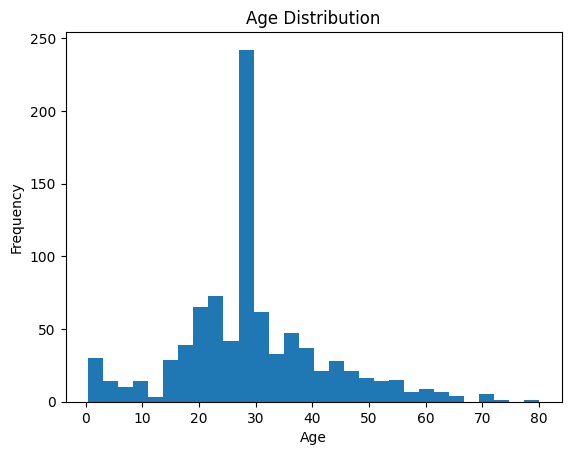

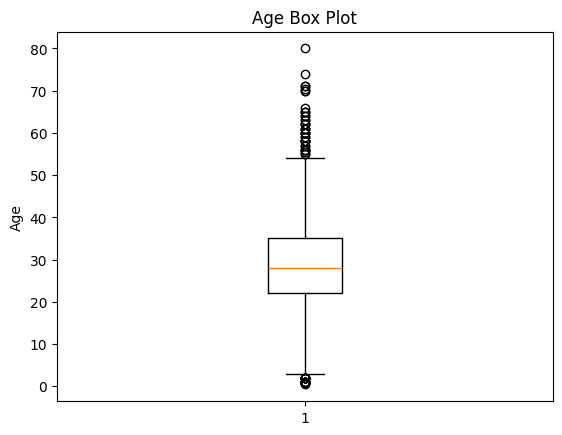

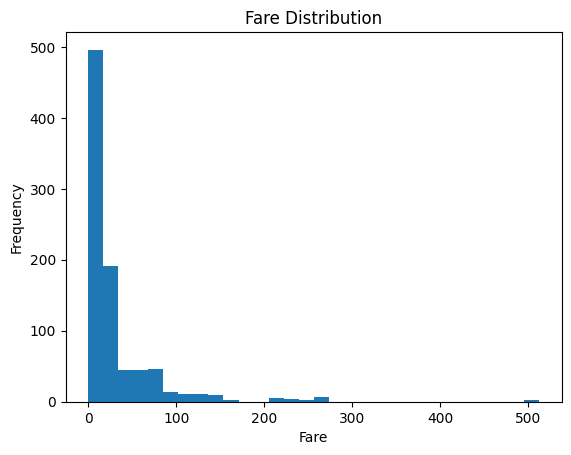

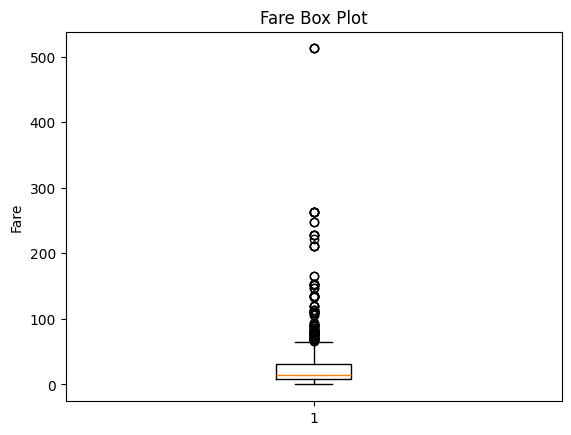

Age outliers: 65
Fare outliers: 114
Fare mean: 32.09668087739032
Fare median: 14.4542
Fare mode: 8.05
Fare distribution is right-skewed


In [6]:
fig, ax = plt.subplots()
ax.hist(df["age"].dropna(), bins=30)
ax.set_title("Age Distribution")
ax.set_xlabel("Age")
ax.set_ylabel("Frequency")
plt.savefig("charts/age_histogram.png")
plt.show()

fig, ax = plt.subplots()
ax.boxplot(df["age"].dropna())
ax.set_title("Age Box Plot")
ax.set_ylabel("Age")
plt.savefig("charts/age_boxplot.png")
plt.show()

fig, ax = plt.subplots()
ax.hist(df["fare"].dropna(), bins=30)
ax.set_title("Fare Distribution")
ax.set_xlabel("Fare")
ax.set_ylabel("Frequency")
plt.savefig("charts/fare_histogram.png")
plt.show()

fig, ax = plt.subplots()
ax.boxplot(df["fare"].dropna())
ax.set_title("Fare Box Plot")
ax.set_ylabel("Fare")
plt.savefig("charts/fare_boxplot.png")
plt.show()

age = df["age"].dropna()
fare = df["fare"].dropna()

q1_age = age.quantile(0.25)
q3_age = age.quantile(0.75)
iqr_age = q3_age - q1_age

age_lower = q1_age - 1.5 * iqr_age
age_upper = q3_age + 1.5 * iqr_age

age_outliers = ((age < age_lower) | (age > age_upper)).sum()

q1_fare = fare.quantile(0.25)
q3_fare = fare.quantile(0.75)
iqr_fare = q3_fare - q1_fare

fare_lower = q1_fare - 1.5 * iqr_fare
fare_upper = q3_fare + 1.5 * iqr_fare

fare_outliers = ((fare < fare_lower) | (fare > fare_upper)).sum()

fare_mean = fare.mean()
fare_median = fare.median()
fare_mode = fare.mode()[0]

print("Age outliers:", age_outliers)
print("Fare outliers:", fare_outliers)

print("Fare mean:", fare_mean)
print("Fare median:", fare_median)
print("Fare mode:", fare_mode)

if fare_mean > fare_median > fare_mode:
    print("Fare distribution is right-skewed")
elif fare_mean < fare_median < fare_mode:
    print("Fare distribution is left-skewed")
else:
    print("Fare distribution is approximately symmetric")

Survival rate by sex:
sex
female    0.740385
male      0.188908
Name: survived, dtype: float64

Survival rate by passenger class:
pclass
1    0.626168
2    0.472826
3    0.242363
Name: survived, dtype: float64

Survival rate by sex and passenger class:
sex     pclass
female  1         0.967391
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: survived, dtype: float64

Female first class survival rate: 0.967391304347826
Male third class survival rate: 0.13544668587896252

Correlation matrix:
          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.335549 -0.069822 -0.034040  0.083151  0.255290
pclass   -0.335549  1.000000 -0.336512  0.081656  0.016824 -0.548193
age      -0.069822 -0.336512  1.000000 -0.232543 -0.171485  0.093707
sibsp    -0.034040  0.081656 -0.232543  1.000000  0.414542  0.160887
parch     0.083151  0.016824 -0.171485  0.414542  1.000000  0.217532

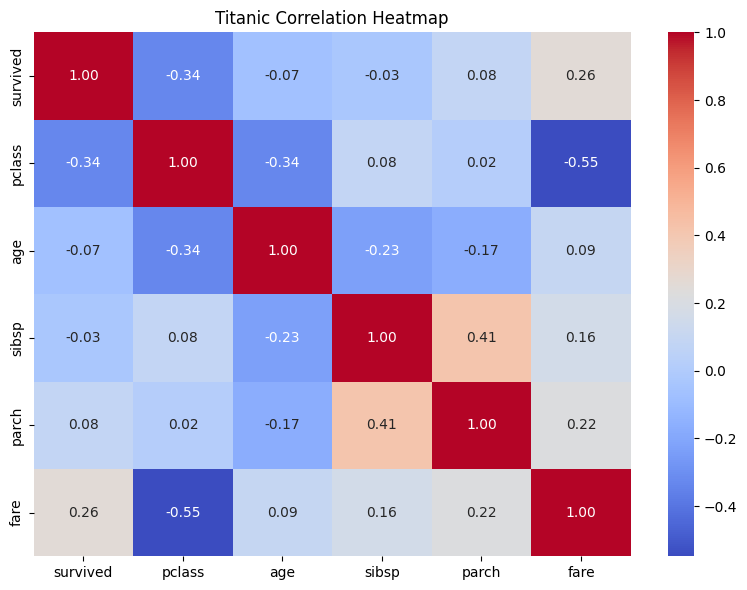


Two strongest correlations:
pclass and fare : -0.5481932852366449
sibsp and parch : 0.4145416380997264


In [7]:
sex_survival = df.groupby("sex")["survived"].mean()
pclass_survival = df.groupby("pclass")["survived"].mean()
sex_pclass_survival = df.groupby(["sex", "pclass"])["survived"].mean()

print("Survival rate by sex:")
print(sex_survival)

print("\nSurvival rate by passenger class:")
print(pclass_survival)

print("\nSurvival rate by sex and passenger class:")
print(sex_pclass_survival)

female_first = df[(df["sex"] == "female") & (df["pclass"] == 1)]
male_third = df[(df["sex"] == "male") & (df["pclass"] == 3)]

print("\nFemale first class survival rate:", female_first["survived"].mean())
print("Male third class survival rate:", male_third["survived"].mean())

corr_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

corr = df[corr_columns].corr()

print("\nCorrelation matrix:")
print(corr)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Titanic Correlation Heatmap")
plt.tight_layout()
plt.savefig("charts/correlation_heatmap.png")
plt.show()

pairs = []

for i in range(len(corr_columns)):
    for j in range(i + 1, len(corr_columns)):
        pairs.append(
            (corr_columns[i], corr_columns[j], corr.iloc[i, j], abs(corr.iloc[i, j]))
        )

pairs = sorted(pairs, key=lambda x: x[3], reverse=True)

print("\nTwo strongest correlations:")

for pair in pairs[:2]:
    print(pair[0], "and", pair[1], ":", pair[2])

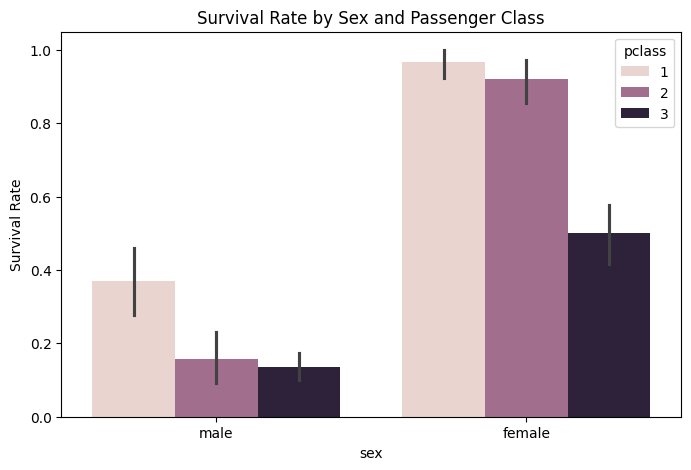

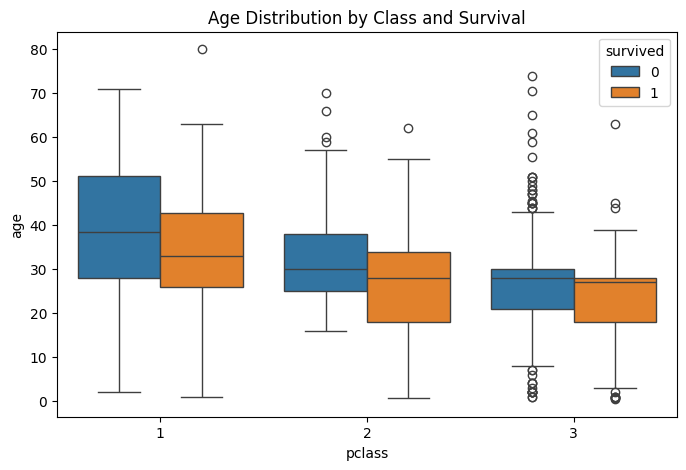

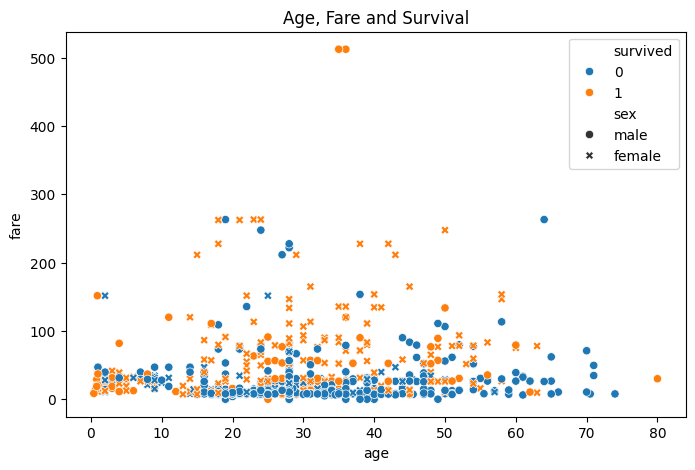

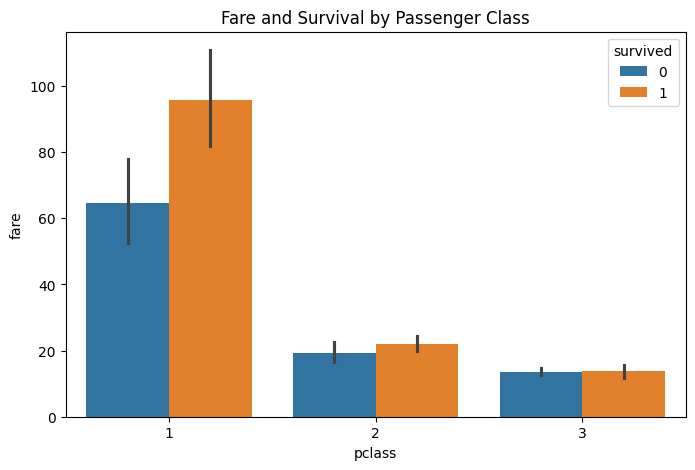

In [8]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="sex", y="survived", hue="pclass")
plt.title("Survival Rate by Sex and Passenger Class")
plt.ylabel("Survival Rate")
plt.savefig("charts/survival_sex_pclass.png")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="pclass", y="age", hue="survived")
plt.title("Age Distribution by Class and Survival")
plt.savefig("charts/age_class_survival.png")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="age", y="fare", hue="survived", style="sex")
plt.title("Age, Fare and Survival")
plt.savefig("charts/age_fare_survival.png")
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="pclass", y="fare", hue="survived")
plt.title("Fare and Survival by Passenger Class")
plt.savefig("charts/fare_class_survival.png")
plt.show()

Before standardization:
            age       fare
mean  29.315152  32.096681
std   12.984932  49.697504

After standardization:
        age_scaled   fare_scaled
mean  2.717486e-16  1.398706e-16
std   1.000563e+00  1.000563e+00


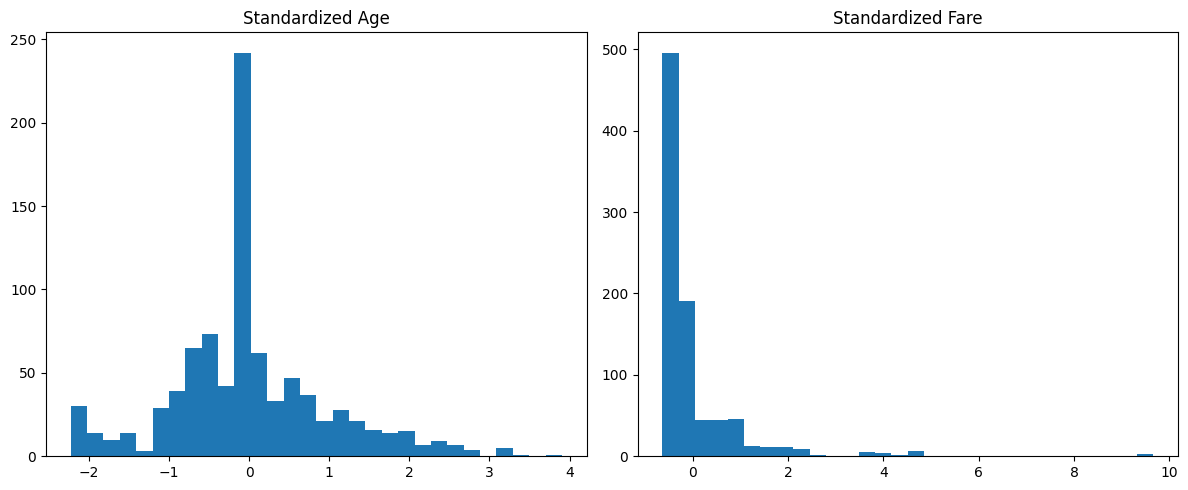

In [9]:
from sklearn.preprocessing import StandardScaler

scale_data = df[["age", "fare"]].copy()

scaler = StandardScaler()
scaled = scaler.fit_transform(scale_data)

scaled_df = pd.DataFrame(
    scaled,
    columns=["age_scaled", "fare_scaled"],
    index=scale_data.index
)

print("Before standardization:")
print(scale_data.agg(["mean", "std"]))

print("\nAfter standardization:")
print(scaled_df.agg(["mean", "std"]))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(scaled_df["age_scaled"].dropna(), bins=30)
axes[0].set_title("Standardized Age")

axes[1].hist(scaled_df["fare_scaled"].dropna(), bins=30)
axes[1].set_title("Standardized Fare")

plt.tight_layout()
plt.savefig("charts/standardized_age_fare.png")
plt.show()

In [10]:
import pandas as pd
import numpy as np

df = pd.read_csv("titanic.csv")

df["age"] = df["age"].fillna(df["age"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

X = df.drop("survived", axis=1)
y = df["survived"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Full class balance:")
print(y.value_counts(normalize=True))

print("\nTraining class balance:")
print(y_train.value_counts(normalize=True))

print("\nTesting class balance:")
print(y_test.value_counts(normalize=True))

Full class balance:
survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

Training class balance:
survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64

Testing class balance:
survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64


In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

categorical_features = [
    "sex",
    "embarked"
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created")

Preprocessing pipeline created


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(max_depth=5, random_state=42))
])

forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)
tree_model.fit(X_train, y_train)
forest_model.fit(X_train, y_train)

print("All three models trained")

All three models trained


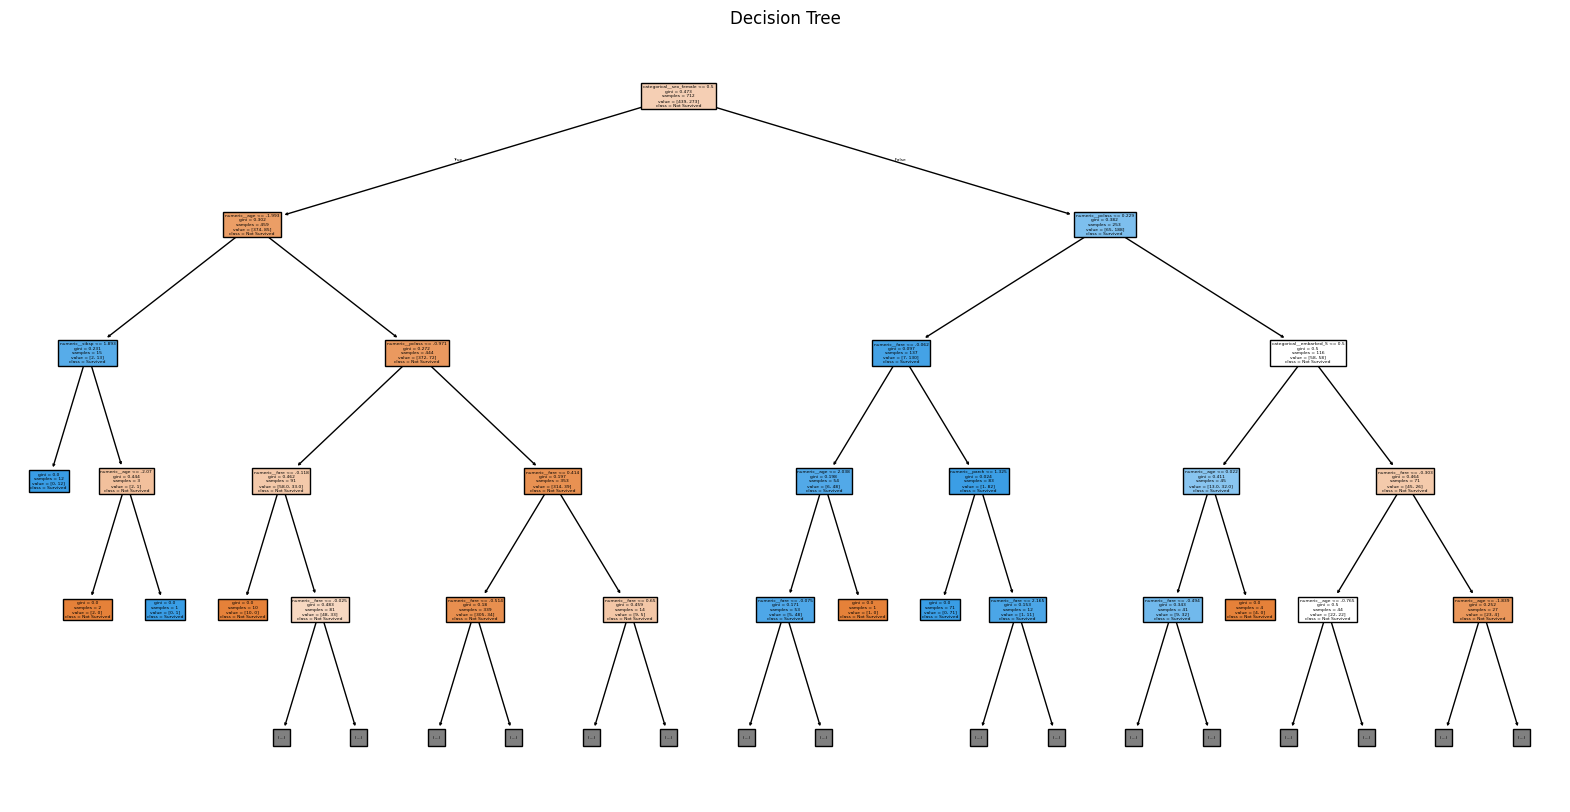

In [13]:
feature_names = tree_model.named_steps["preprocessor"].get_feature_names_out()

plt.figure(figsize=(20, 10))

plot_tree(
    tree_model.named_steps["model"],
    feature_names=feature_names,
    class_names=["Not Survived", "Survived"],
    filled=True,
    max_depth=4
)

plt.title("Decision Tree")
plt.savefig("charts/decision_tree.png")
plt.show()


 Logistic Regression
Confusion Matrix:
[[98 12]
 [23 46]]
Accuracy: 0.8044692737430168
Precision: 0.7931034482758621
Recall: 0.6666666666666666
F1: 0.7244094488188977
AUC: 0.844532279314888

 Decision Tree
Confusion Matrix:
[[97 13]
 [29 40]]
Accuracy: 0.7653631284916201
Precision: 0.7547169811320755
Recall: 0.5797101449275363
F1: 0.6557377049180327
AUC: 0.7971014492753623

 Random Forest
Confusion Matrix:
[[99 11]
 [20 49]]
Accuracy: 0.8268156424581006
Precision: 0.8166666666666667
Recall: 0.7101449275362319
F1: 0.7596899224806202
AUC: 0.8314229249011857


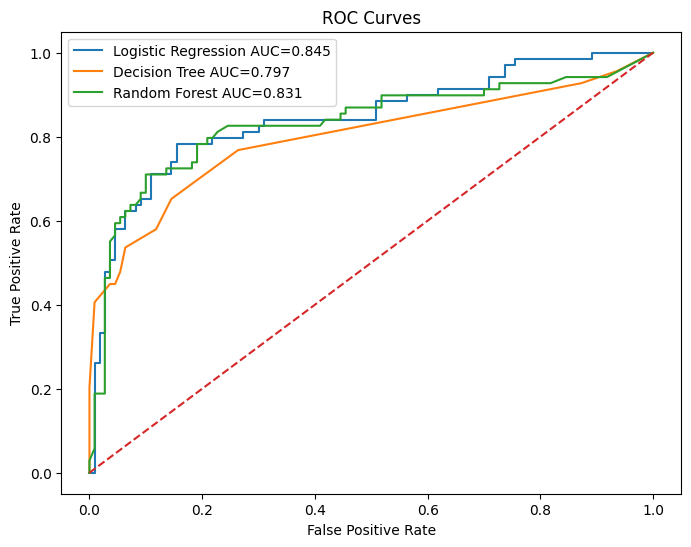


Model comparison:
                 Model  Accuracy  Precision  Recall      F1     AUC
0  Logistic Regression    0.8045     0.7931  0.6667  0.7244  0.8445
1        Decision Tree    0.7654     0.7547  0.5797  0.6557  0.7971
2        Random Forest    0.8268     0.8167  0.7101  0.7597  0.8314


In [14]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    ConfusionMatrixDisplay
)

models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": tree_model,
    "Random Forest": forest_model
}

results = []

plt.figure(figsize=(8, 6))

for name, model in models.items():
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    cm = confusion_matrix(y_test, predictions)

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    auc = roc_auc_score(y_test, probabilities)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        auc
    ])

    fpr, tpr, _ = roc_curve(y_test, probabilities)

    plt.plot(fpr, tpr, label=f"{name} AUC={auc:.3f}")

    print("\n", name)
    print("Confusion Matrix:")
    print(cm)
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)
    print("AUC:", auc)

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.savefig("charts/roc_curves.png")
plt.show()

comparison = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1", "AUC"]
)

print("\nModel comparison:")
print(comparison.round(4))

In [15]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

balanced_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

smote_model = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=1000))
])

imbalance_models = {
    "Baseline": baseline_model,
    "Class Weight Balanced": balanced_model,
    "SMOTE": smote_model
}

imbalance_results = []

print("Class balance:")
print(y.value_counts())
print(y.value_counts(normalize=True))

for name, model in imbalance_models.items():
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    imbalance_results.append([
        name,
        precision,
        recall,
        f1
    ])

imbalance_table = pd.DataFrame(
    imbalance_results,
    columns=["Method", "Precision", "Recall", "F1"]
)

print("\nImbalance comparison:")
print(imbalance_table.round(4))

Class balance:
survived
0    549
1    342
Name: count, dtype: int64
survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

Imbalance comparison:
                  Method  Precision  Recall      F1
0               Baseline     0.7931  0.6667  0.7244
1  Class Weight Balanced     0.7297  0.7826  0.7552
2                  SMOTE     0.7397  0.7826  0.7606


In [16]:
best_imbalance = imbalance_table.loc[
    imbalance_table["F1"].idxmax()
]

print(
    f"The best imbalance strategy based on F1 score was "
    f"{best_imbalance['Method']} with an F1 score of "
    f"{best_imbalance['F1']:.4f}."
)

The best imbalance strategy based on F1 score was SMOTE with an F1 score of 0.7606.


In [17]:
from sklearn.model_selection import GridSearchCV

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42,
        oob_score=True
    ))
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, None],
    "model__max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV score:")
print(grid_search.best_score_)

print("\nOOB score:")
print(best_rf.named_steps["model"].oob_score_)

Best parameters:
{'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__n_estimators': 100}

Best CV score:
0.7452284893229187

OOB score:
0.8061797752808989


MAE: 17.289153132945714
RMSE: 28.97278379809953
R2: 0.4575377190208162
Adjusted R2: 0.3386418766144197


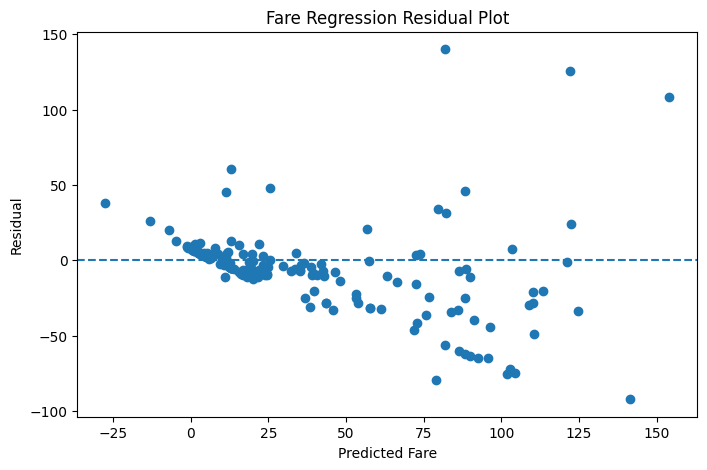

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

reg_df = pd.read_csv("titanic.csv")

reg_df = reg_df.drop(columns=["fare"])

X_reg = reg_df.drop("fare", axis=1) if "fare" in reg_df.columns else None

reg_df = pd.read_csv("titanic.csv")

y_reg = reg_df["fare"]
X_reg = reg_df.drop("fare", axis=1)

numeric_reg = X_reg.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_reg = X_reg.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

reg_preprocessor = ColumnTransformer([
    (
        "numeric",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]),
        numeric_reg
    ),
    (
        "categorical",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]),
        categorical_reg
    )
])

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

regression_model = Pipeline([
    ("preprocessor", reg_preprocessor),
    ("model", LinearRegression())
])

regression_model.fit(X_train_reg, y_train_reg)

reg_predictions = regression_model.predict(X_test_reg)

mae = mean_absolute_error(y_test_reg, reg_predictions)
rmse = np.sqrt(mean_squared_error(y_test_reg, reg_predictions))
r2 = r2_score(y_test_reg, reg_predictions)

n = len(y_test_reg)
p = regression_model.named_steps["preprocessor"].transform(X_test_reg).shape[1]

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)
print("Adjusted R2:", adjusted_r2)

residuals = y_test_reg - reg_predictions

plt.figure(figsize=(8, 5))
plt.scatter(reg_predictions, residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Fare")
plt.ylabel("Residual")
plt.title("Fare Regression Residual Plot")
plt.savefig("charts/residual_plot.png")
plt.show()

In [20]:
best_rf_predictions = best_rf.predict(X_test)
best_rf_probabilities = best_rf.predict_proba(X_test)[:, 1]

best_rf_accuracy = accuracy_score(y_test, best_rf_predictions)
best_rf_precision = precision_score(y_test, best_rf_predictions)
best_rf_recall = recall_score(y_test, best_rf_predictions)
best_rf_f1 = f1_score(y_test, best_rf_predictions)
best_rf_auc = roc_auc_score(y_test, best_rf_probabilities)

final_table = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        comparison.loc[comparison["Model"] == "Logistic Regression", "Accuracy"].iloc[0],
        comparison.loc[comparison["Model"] == "Decision Tree", "Accuracy"].iloc[0],
        best_rf_accuracy
    ],
    "Precision": [
        comparison.loc[comparison["Model"] == "Logistic Regression", "Precision"].iloc[0],
        comparison.loc[comparison["Model"] == "Decision Tree", "Precision"].iloc[0],
        best_rf_precision
    ],
    "Recall": [
        comparison.loc[comparison["Model"] == "Logistic Regression", "Recall"].iloc[0],
        comparison.loc[comparison["Model"] == "Decision Tree", "Recall"].iloc[0],
        best_rf_recall
    ],
    "F1": [
        comparison.loc[comparison["Model"] == "Logistic Regression", "F1"].iloc[0],
        comparison.loc[comparison["Model"] == "Decision Tree", "F1"].iloc[0],
        best_rf_f1
    ],
    "AUC": [
        comparison.loc[comparison["Model"] == "Logistic Regression", "AUC"].iloc[0],
        comparison.loc[comparison["Model"] == "Decision Tree", "AUC"].iloc[0],
        best_rf_auc
    ]
})

final_table["MAE"] = [np.nan, np.nan, mae]
final_table["RMSE"] = [np.nan, np.nan, rmse]
final_table["R2"] = [np.nan, np.nan, r2]
final_table["Adjusted R2"] = [np.nan, np.nan, adjusted_r2]

print(final_table.round(4))

                 Model  Accuracy  Precision  Recall      F1     AUC      MAE  \
0  Logistic Regression    0.8045     0.7931  0.6667  0.7244  0.8445      NaN   
1        Decision Tree    0.7654     0.7547  0.5797  0.6557  0.7971      NaN   
2        Random Forest    0.8212     0.8246  0.6812  0.7460  0.8424  17.2892   

      RMSE      R2  Adjusted R2  
0      NaN     NaN          NaN  
1      NaN     NaN          NaN  
2  28.9728  0.4575       0.3386  


In [21]:
import joblib

full_pipeline = best_rf

joblib.dump(
    full_pipeline,
    "best_titanic_pipeline.joblib"
)

loaded_pipeline = joblib.load(
    "best_titanic_pipeline.joblib"
)

sample_input = X_test.iloc[:5]

sample_predictions = loaded_pipeline.predict(sample_input)

print("Pipeline saved successfully")
print("Pipeline loaded successfully")
print("Predictions on raw input:")
print(sample_predictions)

Pipeline saved successfully
Pipeline loaded successfully
Predictions on raw input:
[0 0 0 0 1]
